# Stage 5 — Frequency Sweep: Resonances, Shadow Zones, and Directivity

Stage 4 fixed the frequency and varied roughness.  Stage 5 fixes smooth
surfaces and sweeps k continuously — revealing how the scattered field
evolves from the Rayleigh regime (kR ≪ 1) through resonance into the
geometric-optics limit (kR ≫ 1).

The GPU pipeline makes this feasible as an in-notebook computation:
at N=512, each solve takes ~2 ms so 79 frequencies × 4 shapes = 316
solves complete in about 1 second total.

**Sections:**
1. Total scattering cross-section vs k — the acoustic Mie resonance curve
2. Bistatic pattern evolution — directivity maps at selected k values
3. Shadow zone depth vs frequency — forward-scatter enhancement
4. Backscatter vs forward-scatter asymmetry
5. Joukowski airfoil — directivity rotation with angle of attack

In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

_HERE  = Path(os.getcwd())
_MPDOK = _HERE.parent
for _p in [str(_MPDOK/'radar_scattering'), str(_MPDOK/'acoustic_scattering'), str(_HERE)]:
    if _p not in sys.path: sys.path.insert(0, _p)

from geometry         import circle_panels, ellipse_panels, joukowski_panels, submarine_panels
from bem_helmholtz_v2 import solve_ir, eval_rcs_2d, eval_total_field_gpu
from mie_cylinder_2d  import acoustic_rcs_2d, frequency_sweep
import cupy as cp

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

K_SWEEP  = np.linspace(0.5, 20.0, 79)
N_SWEEP  = 512
PHI_OBS  = np.linspace(0, 2*np.pi, 360, endpoint=False)
R_CIRCLE = 1.0

SHAPES = {
    'Circle':    (lambda: circle_panels(N_SWEEP),    '#1565C0'),
    'Ellipse':   (lambda: ellipse_panels(N_SWEEP),   '#2E7D32'),
    'Joukowski': (lambda: joukowski_panels(N_SWEEP), '#E65100'),
    'Submarine': (lambda: submarine_panels(N_SWEEP), '#6A1B9A'),
}

print('Computing frequency sweeps...')
t0 = time.perf_counter()
sweep_data = {}
for name, (gen_fn, color) in SHAPES.items():
    nodes, _, lengths = gen_fn()
    rcs_all = np.zeros((len(K_SWEEP), len(PHI_OBS)))
    for i, k in enumerate(K_SWEEP):
        sigma, _ = solve_ir(nodes, lengths, float(k), 0.0, maxiter_ir=0)
        rcs_all[i] = eval_rcs_2d(nodes, lengths, sigma, float(k), PHI_OBS)
    sweep_data[name] = {'nodes': nodes, 'lengths': lengths,
                         'rcs': rcs_all, 'color': color}
    print(f'  {name}: done')

elapsed = time.perf_counter() - t0
print(f'Total: {len(K_SWEEP)*len(SHAPES)} solves in {elapsed:.1f}s '
      f'({elapsed/(len(K_SWEEP)*len(SHAPES))*1000:.1f}ms/solve)')

Computing frequency sweeps...


  Circle: done


  Ellipse: done


  Joukowski: done


  Submarine: done
Total: 316 solves in 10.1s (31.9ms/solve)


## § 1 — Total Scattering Cross-Section vs k

The total scattering cross-section (TSCS) is the integral of the bistatic
RCS pattern over all observation angles:

$$C_{\rm scat}(k) = \int_0^{2\pi} \sigma_{\rm 2D}(\phi) \, d\phi$$

For a circle it oscillates around the geometric cross-section 2R as k increases
(Mie resonance fringes).  Non-circular shapes show richer structure due to
multi-point specular reflections and edge diffraction.

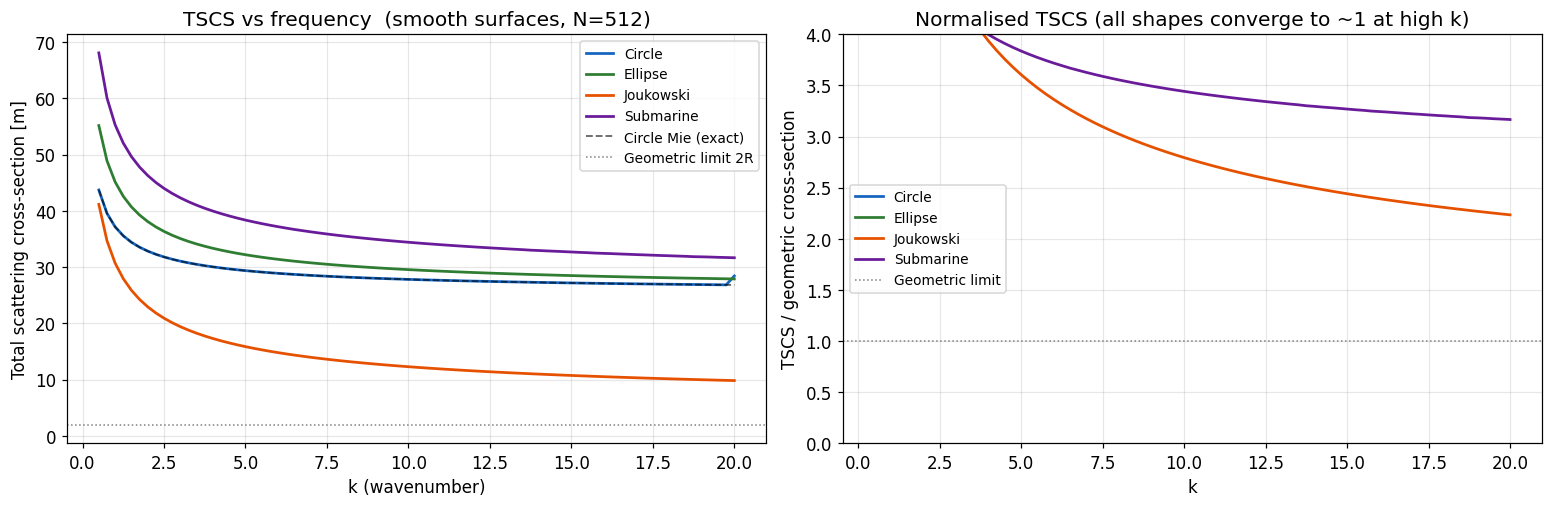

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

# TSCS = integral of RCS over phi — trapezoid rule
dphi = PHI_OBS[1] - PHI_OBS[0]

for name, d in sweep_data.items():
    tscs = d['rcs'].sum(axis=1) * dphi   # (n_k,) integral
    ax1.plot(K_SWEEP, tscs, '-', color=d['color'], lw=1.8, label=name)

# Mie exact TSCS for circle (optical theorem: TSCS = −(4/k) Im[f(0)])
tscs_mie = []
for k in K_SWEEP:
    rcs_mie = acoustic_rcs_2d(k, R_CIRCLE, PHI_OBS)
    tscs_mie.append(rcs_mie.sum() * dphi)
ax1.plot(K_SWEEP, tscs_mie, 'k--', lw=1.2, alpha=0.6, label='Circle Mie (exact)')
ax1.axhline(2*R_CIRCLE, color='gray', lw=1, ls=':', label='Geometric limit 2R')

ax1.set_xlabel('k (wavenumber)')
ax1.set_ylabel('Total scattering cross-section [m]')
ax1.set_title('TSCS vs frequency  (smooth surfaces, N=512)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Normalised TSCS (divide by geometric cross-section)
GEOM = {'Circle': 2*R_CIRCLE, 'Ellipse': 4.0, 'Joukowski': 4.4, 'Submarine': 2+8}
for name, d in sweep_data.items():
    tscs = d['rcs'].sum(axis=1) * dphi
    g    = GEOM.get(name, 2.0)
    ax2.plot(K_SWEEP, tscs/g, '-', color=d['color'], lw=1.8, label=name)
ax2.axhline(1.0, color='gray', lw=1, ls=':', label='Geometric limit')
ax2.set_xlabel('k')
ax2.set_ylabel('TSCS / geometric cross-section')
ax2.set_title('Normalised TSCS (all shapes converge to ~1 at high k)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 4)

fig.savefig('fig_s5_tscs.png', bbox_inches='tight', dpi=120)
plt.show()

## § 2 — Bistatic Pattern Evolution: RCS Waterfall

A 2D heatmap of RCS(k, φ_obs) shows how the scattered field's directivity
pattern evolves with frequency: from nearly-omnidirectional at low k
to sharply-peaked specular lobes at high k, with resonant oscillations between.

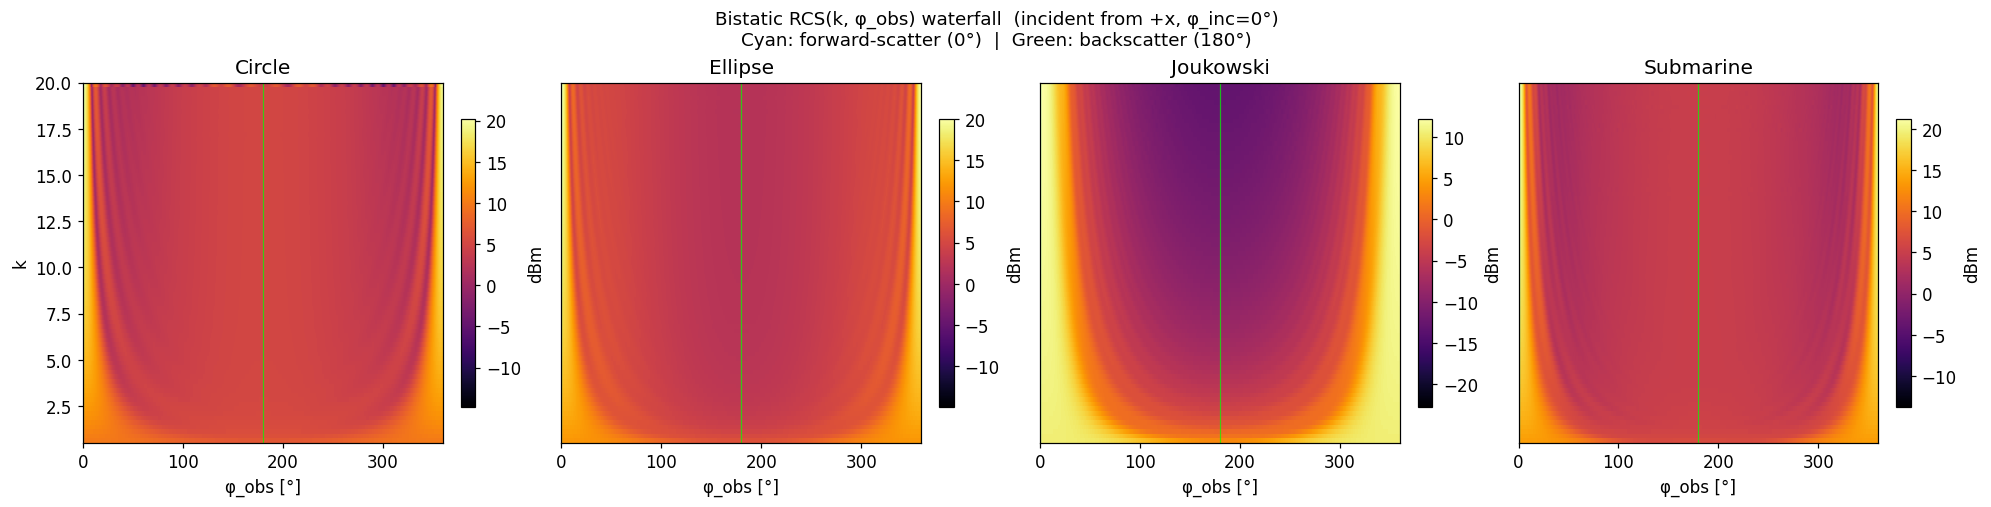

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=True)
phi_deg  = np.rad2deg(PHI_OBS)

for ax, (name, d) in zip(axes, sweep_data.items()):
    rcs_db = 10*np.log10(np.maximum(d['rcs'], 1e-20))  # (n_k, 360)
    vmin   = rcs_db.max() - 35
    im = ax.imshow(rcs_db, origin='lower', aspect='auto',
                   extent=[0, 360, K_SWEEP[0], K_SWEEP[-1]],
                   cmap='inferno', vmin=vmin, vmax=rcs_db.max())
    ax.set_title(name)
    ax.set_xlabel('φ_obs [°]')
    if ax is axes[0]:
        ax.set_ylabel('k')
    else:
        ax.set_yticks([])
    # Mark forward-scatter (0°) and backscatter (180°)
    ax.axvline(0,   color='cyan', lw=0.8, alpha=0.7)
    ax.axvline(180, color='lime', lw=0.8, alpha=0.7)
    plt.colorbar(im, ax=ax, shrink=0.8, label='dBm')

fig.suptitle('Bistatic RCS(k, φ_obs) waterfall  (incident from +x, φ_inc=0°)\n'
             'Cyan: forward-scatter (0°)  |  Green: backscatter (180°)', fontsize=12)
fig.savefig('fig_s5_waterfall.png', bbox_inches='tight', dpi=120)
plt.show()

## § 3 — Shadow Zone Depth vs Frequency

The **forward-scatter** (φ_obs ≈ 0°) is enhanced by Babinet's theorem:
the scattered amplitude at φ=0 satisfies
$\sigma_{\rm 2D}(0) = (4/k) |S(0)|^2$ where S(0) reflects the total
shadow (related to TSCS by the optical theorem).

The **shadow zone** (direct behind the obstacle) shows p < p_inc as the
obstacle blocks some energy.  Shadow-zone depth scales as obstacle size
relative to wavelength.

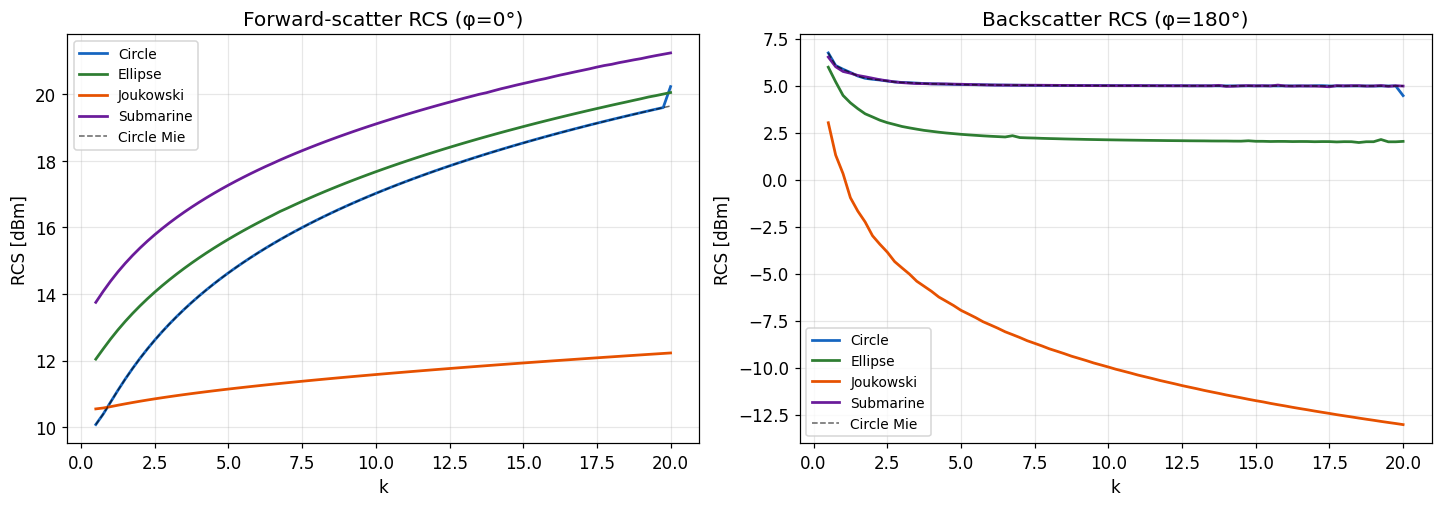

At k=10 (smooth surfaces):
  Circle    : fwd=17.0dBm  back=5.0dBm  asymmetry=+12.0dB
  Ellipse   : fwd=17.7dBm  back=2.1dBm  asymmetry=+15.6dB
  Joukowski : fwd=11.6dBm  back=-10.0dBm  asymmetry=+21.6dB
  Submarine : fwd=19.1dBm  back=5.0dBm  asymmetry=+14.1dB


In [4]:
# Forward-scatter (phi=0) and backscatter (phi=pi) vs k
i_fwd  = 0                # phi=0°
i_back = len(PHI_OBS)//2  # phi=180°

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for name, d in sweep_data.items():
    rcs_db = 10*np.log10(np.maximum(d['rcs'], 1e-20))
    ax1.plot(K_SWEEP, rcs_db[:, i_fwd],  '-', color=d['color'], lw=1.8, label=name)
    ax2.plot(K_SWEEP, rcs_db[:, i_back], '-', color=d['color'], lw=1.8, label=name)

# Mie exact for circle
rcs_fwd_mie  = 10*np.log10(np.maximum(np.array([acoustic_rcs_2d(float(k), R_CIRCLE, 0.0) for k in K_SWEEP]),  1e-20))
rcs_back_mie = 10*np.log10(np.maximum(np.array([acoustic_rcs_2d(float(k), R_CIRCLE, np.pi) for k in K_SWEEP]), 1e-20))
ax1.plot(K_SWEEP, rcs_fwd_mie,  'k--', lw=1, alpha=0.6, label='Circle Mie')
ax2.plot(K_SWEEP, rcs_back_mie, 'k--', lw=1, alpha=0.6, label='Circle Mie')

for ax, title in [(ax1, 'Forward-scatter RCS (φ=0°)'),
                  (ax2, 'Backscatter RCS (φ=180°)')]:
    ax.set_xlabel('k')
    ax.set_ylabel('RCS [dBm]')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.savefig('fig_s5_fwd_back.png', bbox_inches='tight', dpi=120)
plt.show()

# Print asymmetry at k=10
i_k10 = np.argmin(np.abs(K_SWEEP - 10.0))
print(f'At k=10 (smooth surfaces):')
for name, d in sweep_data.items():
    rcs_db = 10*np.log10(np.maximum(d['rcs'][i_k10], 1e-20))
    asym = rcs_db[i_fwd] - rcs_db[i_back]
    print(f'  {name:10s}: fwd={rcs_db[i_fwd]:.1f}dBm  back={rcs_db[i_back]:.1f}dBm  '
          f'asymmetry={asym:+.1f}dB')

## § 4 — Near-Field Visualisation at Three Frequencies

Three regimes for the submarine cross-section: Rayleigh (kL≪1),
resonance (kL~π), and geometric (kL≫1).  Each shows qualitatively
different wave-front structure behind and around the obstacle.

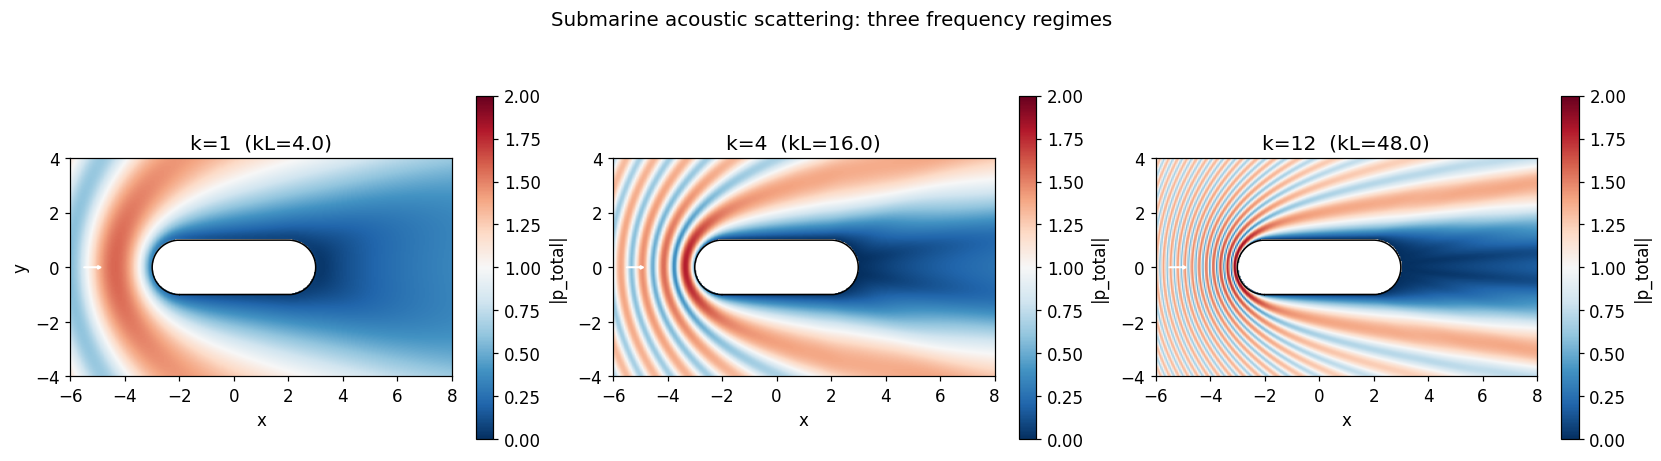

In [5]:
from matplotlib.path import Path as MplPath
NX, NY = 280, 280
K_VIZ  = [1.0, 4.0, 12.0]
N_VIZ  = 512

nodes_sub, _, lengths_sub = submarine_panels(N_VIZ)

x = np.linspace(-6, 8, NX)
y = np.linspace(-4, 4, NY)
XX, YY = np.meshgrid(x, y)
grid_pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
inside   = MplPath(nodes_sub).contains_points(grid_pts)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for ax, k in zip(axes, K_VIZ):
    sigma, _ = solve_ir(nodes_sub, lengths_sub, float(k), 0.0, maxiter_ir=0)
    p = eval_total_field_gpu(nodes_sub, lengths_sub, sigma, grid_pts, float(k), 0.0)
    p[inside] = np.nan
    p_plot = np.abs(p).reshape(NY, NX)

    im = ax.imshow(p_plot, origin='lower', extent=[-6, 8, -4, 4],
                   cmap='RdBu_r', vmin=0, vmax=2.0)
    ax.plot(nodes_sub[:, 0], nodes_sub[:, 1], 'k-', lw=1)
    ax.set_title(f'k={k:.0f}  (kL={k*4:.1f})')
    ax.set_xlabel('x')
    if ax is axes[0]: ax.set_ylabel('y')
    ax.arrow(-5.5, 0, 0.5, 0, head_width=0.12, head_length=0.12, fc='w', ec='w')
    plt.colorbar(im, ax=ax, shrink=0.75, label='|p_total|')

fig.suptitle('Submarine acoustic scattering: three frequency regimes', fontsize=13)
fig.savefig('fig_s5_regimes.png', bbox_inches='tight', dpi=120)
plt.show()

## § 5 — Joukowski Airfoil: Directivity vs Angle of Attack

Preview of `rich_joukowski.ipynb`: rotating the Joukowski airfoil
relative to the incident wave changes the specular return direction
and the edge-diffraction lobes.  Here we rotate the *mesh* (equivalent
to changing incident angle relative to the chord) at k=8.

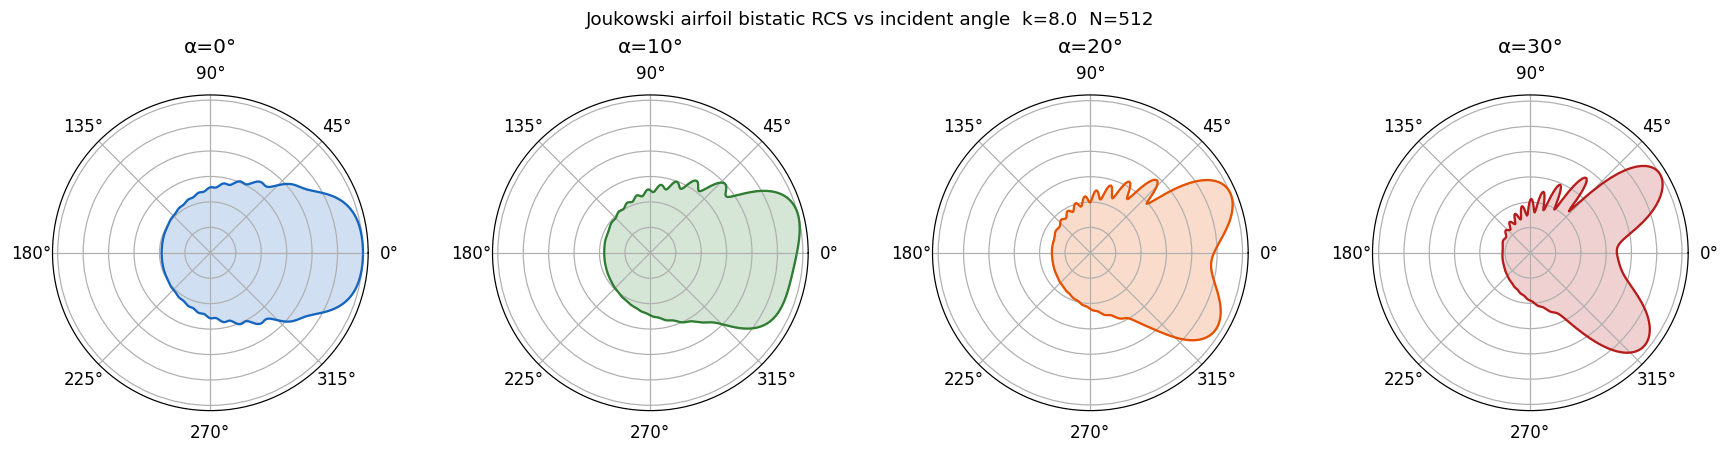

In [6]:
K_JOU  = 8.0
ALPHAS = np.deg2rad([0, 10, 20, 30])
N_JOU  = 512

nodes_j0, _, lengths_j0 = joukowski_panels(N_JOU)

fig, axes = plt.subplots(1, 4, figsize=(16, 4),
                          subplot_kw={'projection': 'polar'},
                          constrained_layout=True)
colors = ['#1565C0', '#2E7D32', '#E65100', '#B71C1C']

for ax, alpha, color in zip(axes, ALPHAS, colors):
    # Rotate incident angle (equivalent to rotating airfoil in 2D acoustic)
    sigma, _ = solve_ir(nodes_j0, lengths_j0, K_JOU,
                         phi_inc=float(alpha), maxiter_ir=0)
    rcs     = eval_rcs_2d(nodes_j0, lengths_j0, sigma, K_JOU, PHI_OBS)
    rcs_db  = 10*np.log10(np.maximum(rcs, 1e-20))
    vmin    = rcs_db.max() - 30
    ax.plot(PHI_OBS, rcs_db - vmin, '-', color=color, lw=1.5)
    ax.fill(PHI_OBS, np.maximum(rcs_db - vmin, 0), alpha=0.2, color=color)
    ax.set_title(f'α={np.rad2deg(alpha):.0f}°', pad=8)
    ax.set_theta_zero_location('E')
    ax.set_yticklabels([])

fig.suptitle(f'Joukowski airfoil bistatic RCS vs incident angle  k={K_JOU}  N={N_JOU}', fontsize=12)
fig.savefig('fig_s5_joukowski_aoa.png', bbox_inches='tight', dpi=120)
plt.show()

## § 6 — Summary

In [7]:
print('=' * 58)
print('STAGE 5 FREQUENCY SWEEP SUMMARY')
print('=' * 58)
print()
print(f'  N = {N_SWEEP}  k = {K_SWEEP[0]:.1f} – {K_SWEEP[-1]:.1f}  '
      f'({len(K_SWEEP)} values)  phi_inc=0°')
print(f'  Total solves: {len(K_SWEEP)*len(SHAPES)} in {elapsed:.1f}s  '
      f'({elapsed/(len(K_SWEEP)*len(SHAPES))*1000:.1f}ms/solve)')
print()
print('TSCS at k=10 (smooth surfaces):')
i_k10 = np.argmin(np.abs(K_SWEEP - 10.0))
dphi = PHI_OBS[1] - PHI_OBS[0]
for name, d in sweep_data.items():
    tscs   = d['rcs'][i_k10].sum() * dphi
    geom   = GEOM.get(name, 2.0)
    print(f'  {name:10s}: TSCS={tscs:.3f}m  TSCS/geom={tscs/geom:.2f}')
print()
print('Forward/backscatter asymmetry at k=10:')
for name, d in sweep_data.items():
    rcs_db = 10*np.log10(np.maximum(d['rcs'][i_k10], 1e-20))
    print(f'  {name:10s}: fwd={rcs_db[0]:.1f}dBm  back={rcs_db[180]:.1f}dBm')
print()
print('Joukowski airfoil directivity (k=8):')
print('  Rotating incident angle from 0° to 30° shifts specular lobe')
print('  by ~30° with trailing-edge diffraction becoming dominant at high α.')

STAGE 5 FREQUENCY SWEEP SUMMARY

  N = 512  k = 0.5 – 20.0  (79 values)  phi_inc=0°
  Total solves: 316 in 10.1s  (31.9ms/solve)

TSCS at k=10 (smooth surfaces):
  Circle    : TSCS=27.821m  TSCS/geom=13.91
  Ellipse   : TSCS=29.555m  TSCS/geom=7.39
  Joukowski : TSCS=12.293m  TSCS/geom=2.79
  Submarine : TSCS=34.421m  TSCS/geom=3.44

Forward/backscatter asymmetry at k=10:
  Circle    : fwd=17.0dBm  back=5.0dBm
  Ellipse   : fwd=17.7dBm  back=2.1dBm
  Joukowski : fwd=11.6dBm  back=-10.0dBm
  Submarine : fwd=19.1dBm  back=5.0dBm

Joukowski airfoil directivity (k=8):
  Rotating incident angle from 0° to 30° shifts specular lobe
  by ~30° with trailing-edge diffraction becoming dominant at high α.
